In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking charts

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
# Identify the correct column name for income/salary to avoid KeyErrors
possible_income_cols = [c for c in df.columns if 'income' in c.lower() or 'salary' in c.lower()]
income_col = possible_income_cols[0] if possible_income_cols else 'MonthlyIncome'

num_cols = ['Age', 'TotalWorkingYears', 'YearsAtCompany',
            'JobSatisfaction', 'DistanceFromHome', income_col]
print(f"Detected income column: {income_col}")

Detected income column: MonthlyIncome


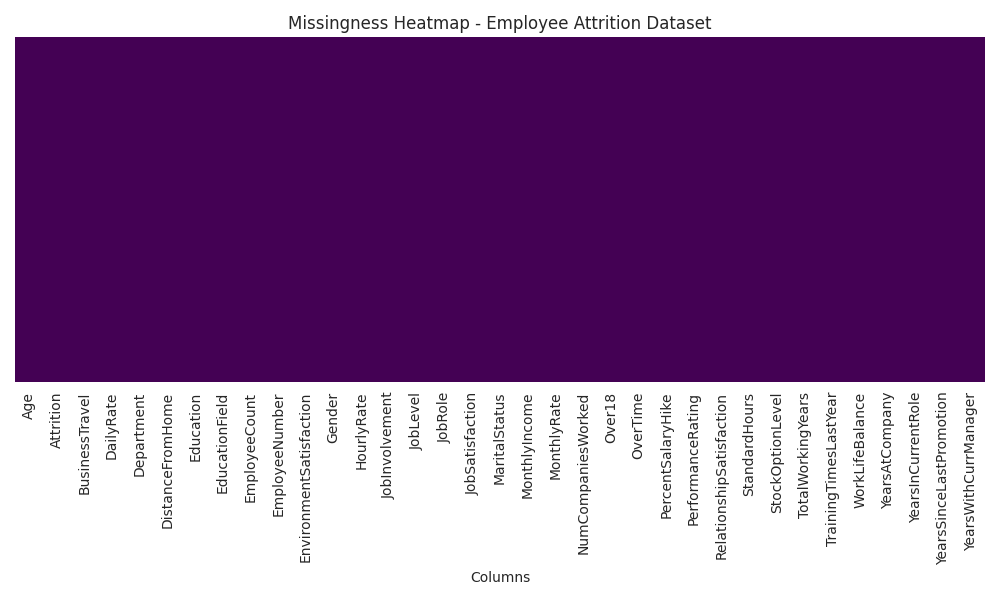

In [4]:
fig1 = plt.figure(figsize = (10, 6))
sns.heatmap(df.isnull(), cbar = False, cmap="viridis", yticklabels = False)
plt.title("Missingness Heatmap - Employee Attrition Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

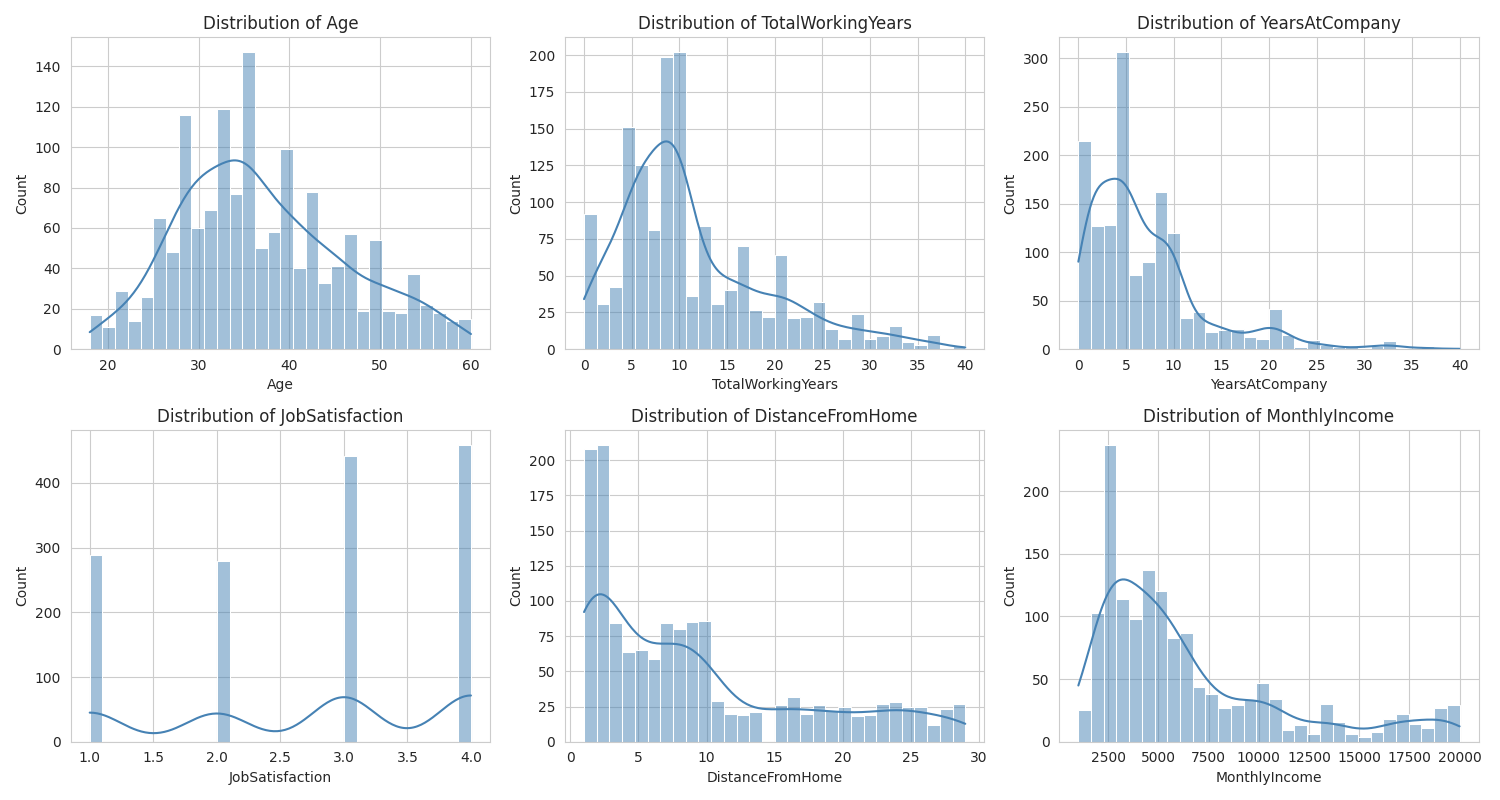

In [5]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    if col in df.columns:
        sns.histplot(df[col].dropna(), bins=30, kde=True,
                     ax=axes[row, colpos], color='steelblue')
        axes[row, colpos].set_title(f'Distribution of {col}')
    else:
        axes[row, colpos].set_title(f'Column {col} not found')

plt.tight_layout()
plt.show()

In [6]:
pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Six Histograms
pdf.close()

In [7]:
from google.colab import files
files.download('EDA_Report.pdf')

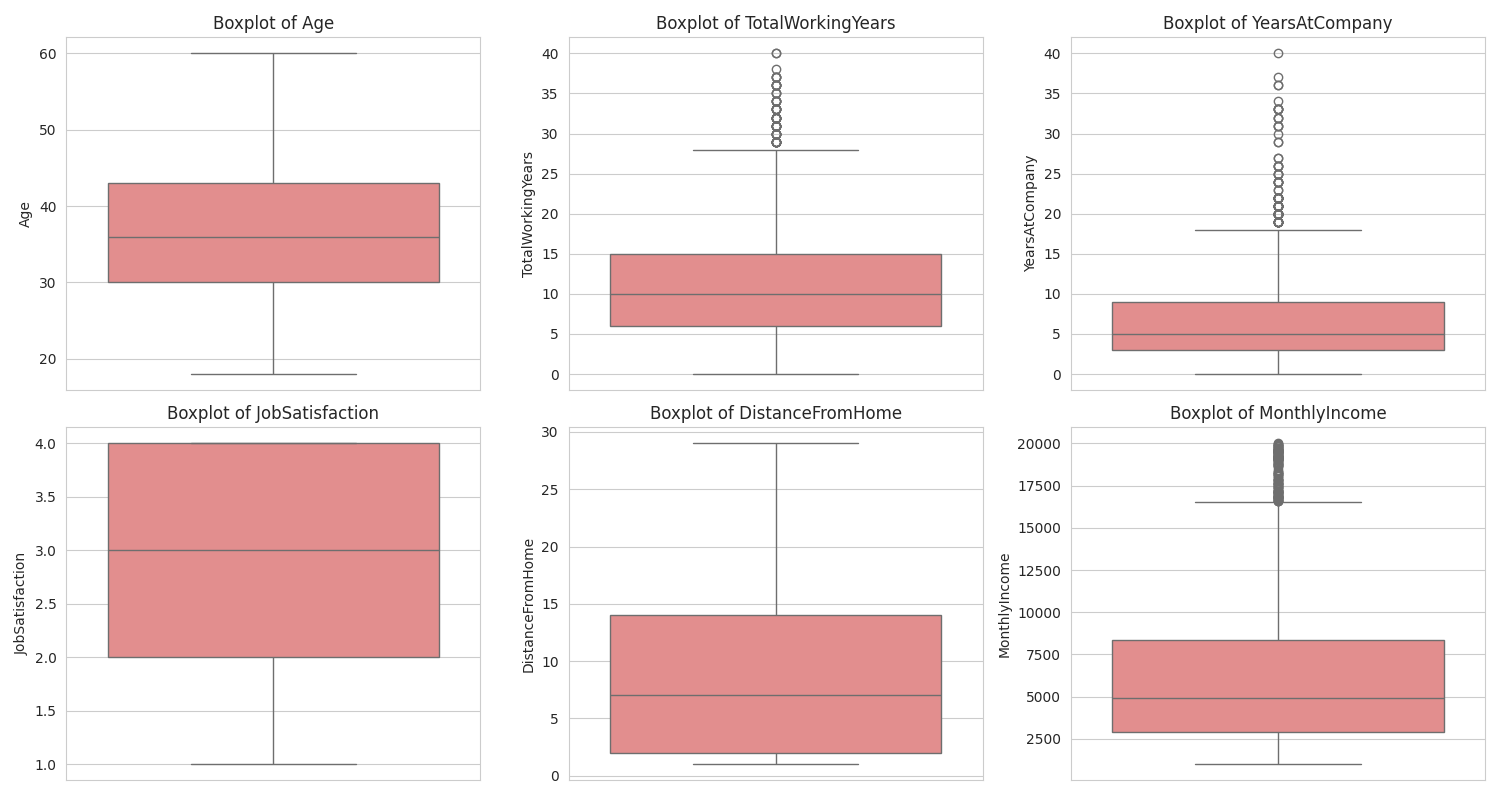

In [8]:
fig3, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [9]:
pdf.savefig(fig3)

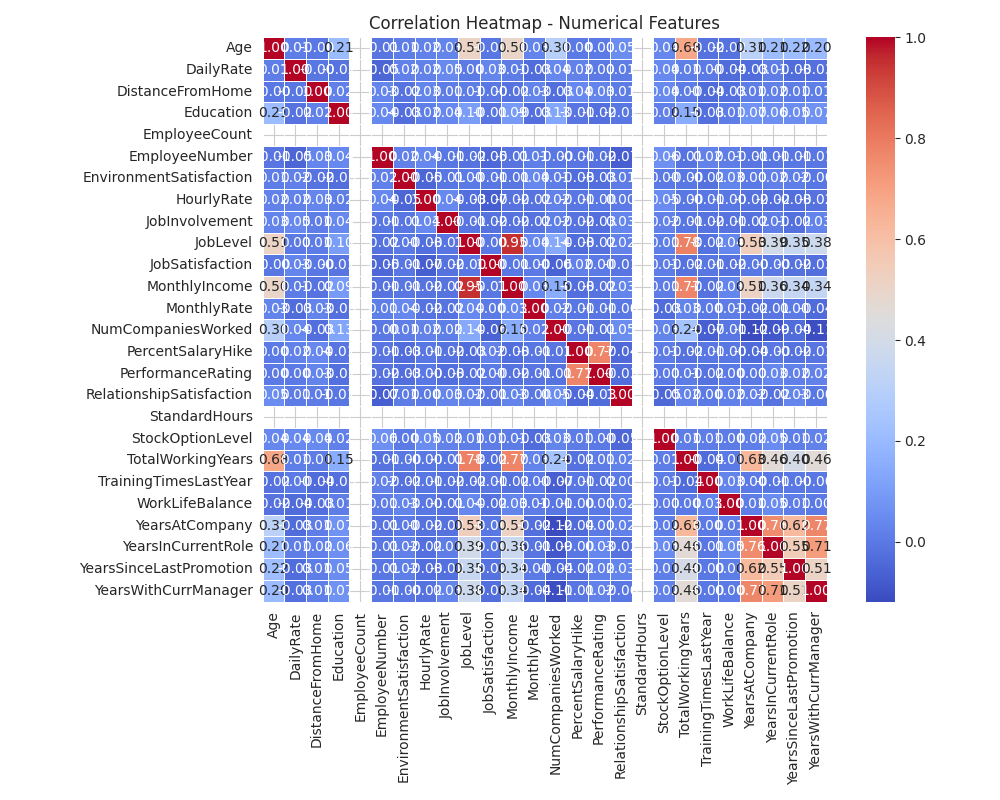

In [10]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()